In [93]:
from pathlib import Path

nabirds_root_path = Path("/local/scratch/datasets/nabirds")

[x.name for x in nabirds_root_path.iterdir()]

['README',
 'sizes.txt',
 'images.txt',
 'classes.txt',
 'parts',
 'hierarchy.txt',
 'image_class_labels.txt',
 'README~',
 'train_test_split.txt',
 'nabirds.py',
 'photographers.txt',
 '__init__.py',
 'bounding_boxes.txt',
 'images']

['0000139e-21dc-4d0c-bfe1-4cae3c85c829', '296', '341']


<Axes: >

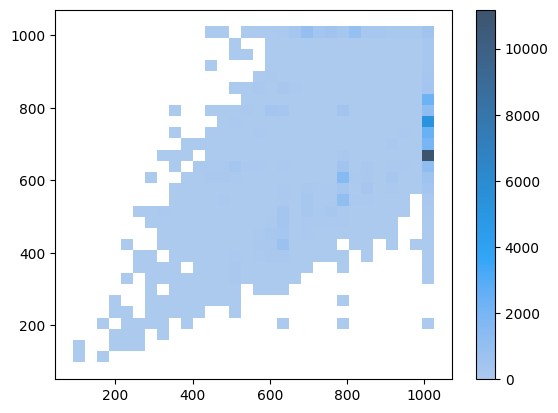

In [94]:
import pandas as pd
import seaborn as sns


with open(nabirds_root_path / "sizes.txt", "r") as f:
    sizes = [line.strip().split() for line in f]

print(sizes[0])

widths = [int(w) for id, w, h in sizes]
heights = [int(h) for id, w, h in sizes]

sns.histplot(x=widths, y=heights, bins=30, kde=True, cbar=True)

#### Image Size
Most are about 1000 in width and 600-800 in height

<Axes: >

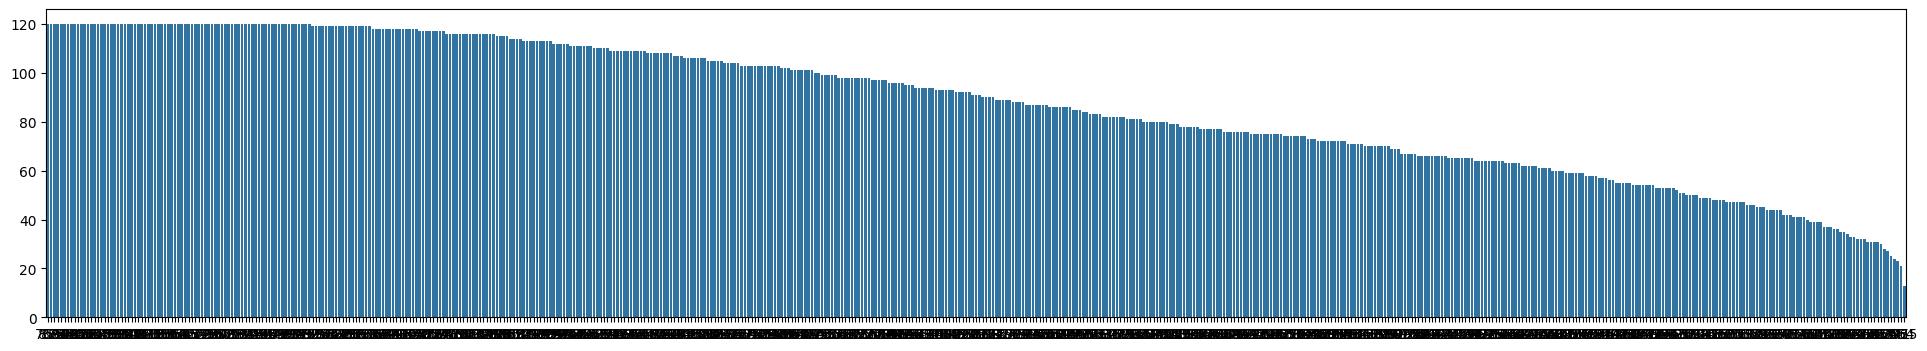

In [95]:
import numpy as np
import matplotlib.pyplot as plt

with open(nabirds_root_path / "image_class_labels.txt", "r") as f:
    classes = [line.strip().split()[1] for line in f]

unique_categories, counts = np.unique(classes, return_counts=True)
sorted_indices = np.argsort(counts)[::-1]

fig, ax = plt.subplots(figsize=(24, 4))

sns.barplot(x=unique_categories, y=counts, order=np.array(unique_categories)[sorted_indices], ax=ax)

In [96]:
counts.mean(), counts.std(), counts.min(), counts.max()

(87.4990990990991, 27.270111994588262, 13, 120)

#### Image counts
Generally balanced with a bit of a tail. Minimum has 13 images, while the max has 120. Averaging 87 images per class.

In [97]:
with open(nabirds_root_path / "images.txt", "r") as f:
    ids, paths = zip(*[line.strip().split() for line in f])

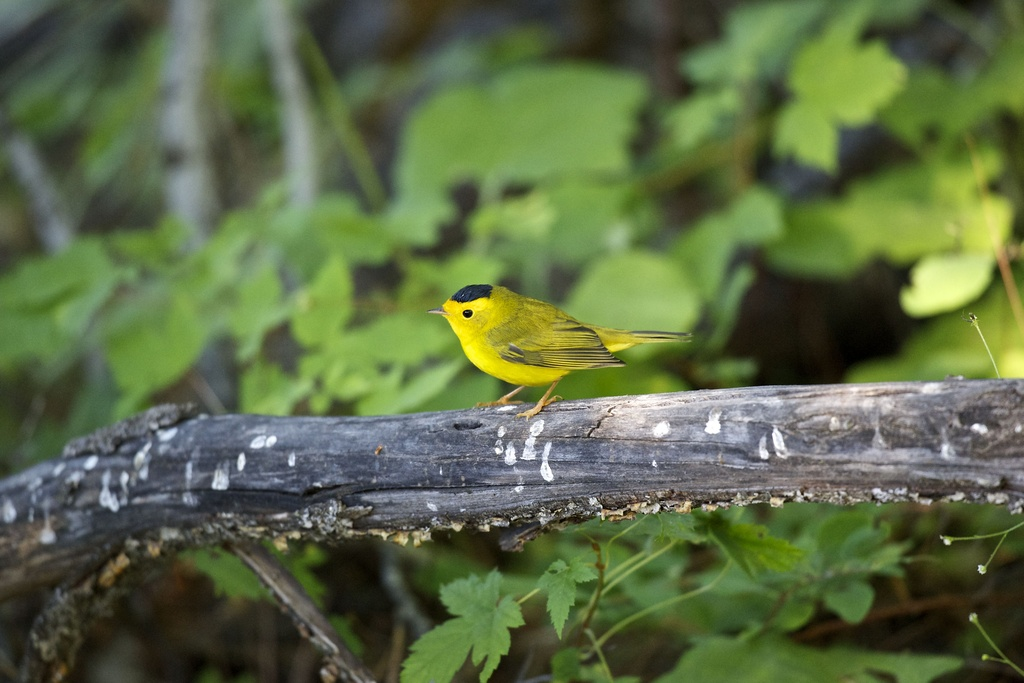

In [98]:
from PIL import Image

IDX = 10657 #267
CUR_ID = ids[IDX]
CUR_PATH = nabirds_root_path / "images" / paths[IDX]

image = Image.open(CUR_PATH)
image

In [99]:
with open(nabirds_root_path / "parts" / "parts.txt", "r") as f:
    part_list = [line.strip().split() for line in f]
    
part_list[:5]

part_lbl_to_name = {part_id: "-".join(part_name) for part_id, *part_name in part_list}

In [100]:
with open(nabirds_root_path / "parts/part_locs.txt", "r") as f:
    part_locs = [line.strip().split() for line in f]
    
part_locs[:5]

[['0000139e-21dc-4d0c-bfe1-4cae3c85c829', '0', '203', '99', '1'],
 ['0000139e-21dc-4d0c-bfe1-4cae3c85c829', '1', '155', '70', '1'],
 ['0000139e-21dc-4d0c-bfe1-4cae3c85c829', '2', '145', '95', '1'],
 ['0000139e-21dc-4d0c-bfe1-4cae3c85c829', '3', '0', '0', '0'],
 ['0000139e-21dc-4d0c-bfe1-4cae3c85c829', '4', '182', '98', '1']]

In [101]:
cur_part_locs = [loc for loc in part_locs if loc[0] == CUR_ID]
cur_part_locs

[['3889542f-aedd-4ccc-a774-4717ba15c56b', '0', '435', '311', '1'],
 ['3889542f-aedd-4ccc-a774-4717ba15c56b', '1', '469', '285', '1'],
 ['3889542f-aedd-4ccc-a774-4717ba15c56b', '2', '512', '298', '1'],
 ['3889542f-aedd-4ccc-a774-4717ba15c56b', '3', '468', '313', '1'],
 ['3889542f-aedd-4ccc-a774-4717ba15c56b', '4', '0', '0', '0'],
 ['3889542f-aedd-4ccc-a774-4717ba15c56b', '5', '524', '375', '1'],
 ['3889542f-aedd-4ccc-a774-4717ba15c56b', '6', '472', '350', '1'],
 ['3889542f-aedd-4ccc-a774-4717ba15c56b', '7', '540', '313', '1'],
 ['3889542f-aedd-4ccc-a774-4717ba15c56b', '8', '661', '337', '1'],
 ['3889542f-aedd-4ccc-a774-4717ba15c56b', '9', '562', '349', '1'],
 ['3889542f-aedd-4ccc-a774-4717ba15c56b', '10', '0', '0', '0']]

In [102]:
with open(nabirds_root_path / "bounding_boxes.txt", "r") as f:
    box_locs = [line.strip().split() for line in f]
    
box_locs[:5]

[['0000139e-21dc-4d0c-bfe1-4cae3c85c829', '83', '59', '128', '228'],
 ['0000d9fc-4e02-4c06-a0af-a55cfb16b12b', '328', '88', '163', '298'],
 ['00019306-9d83-4334-b255-a447742edce3', '174', '367', '219', '378'],
 ['0001afd4-99a1-4a67-b940-d419413e23b3', '307', '179', '492', '224'],
 ['000332b8-997c-4540-9647-2f0a8495aecf', '395', '139', '262', '390']]

In [103]:
cur_box_locs = [loc for loc in box_locs if loc[0] == CUR_ID]
cur_box_locs

[['3889542f-aedd-4ccc-a774-4717ba15c56b', '417', '277', '276', '150']]

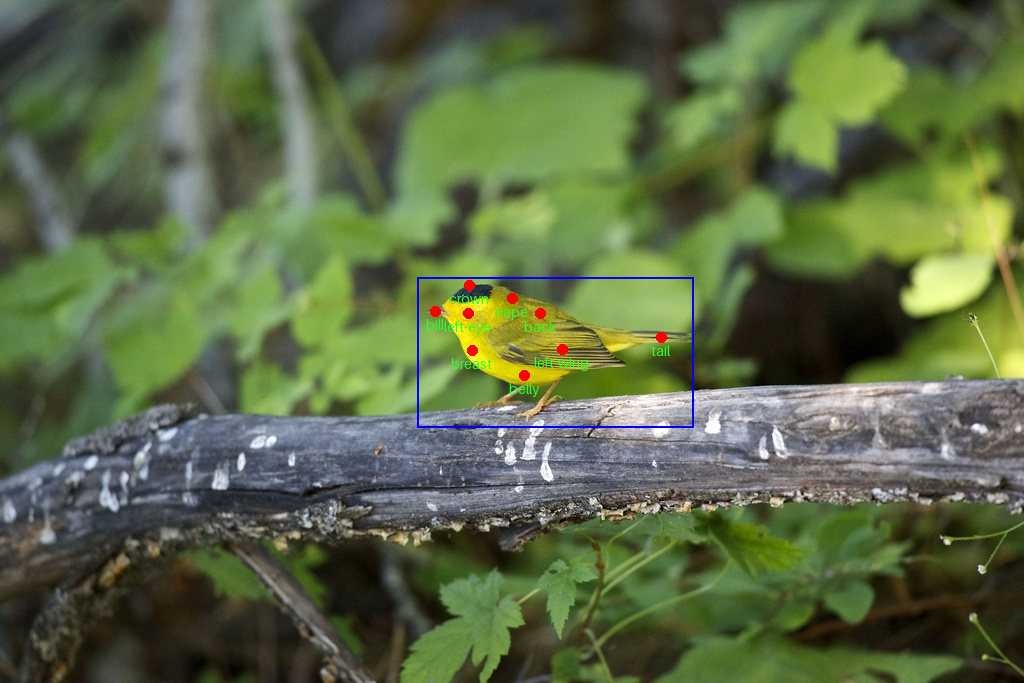

In [105]:
from PIL import ImageDraw, ImageFont

image_with_parts = image.copy()
draw = ImageDraw.Draw(image_with_parts)
font = ImageFont.load_default(size=14) 

radius=5

start_x, start_y, width, height = map(int, cur_box_locs[0][1:5])
draw.rectangle((start_x, start_y, start_x + width, start_y + height), outline="blue", width=2)
for _, part_id, x, y, visible in cur_part_locs:
    if visible == "1":
        draw.ellipse((int(x)-radius, int(y)-radius, int(x)+radius, int(y)+radius), fill="red")
        draw.text((int(x), int(y)+5), part_lbl_to_name[part_id], fill="#2CFF2C", font=font, anchor="ma")
image_with_parts